# 1. Data Preprocessing 🧹
Handling missing values, encoding, and normalization


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

g3efr = pd.read_csv('data.csv')
g3efr = g3efr.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')
g3efr['diagnosis'] = g3efr['diagnosis'].map({'M': 1, 'B': 0})
g3efr = g3efr.fillna(g3efr.mean())

## 1.1 Train/Test Split and Scaling


In [37]:
X = g3efr.drop('diagnosis', axis=1)
y = g3efr['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# 2. Naive Bayes Implementation 🧠
## 2.1 GaussianNB Class & Training


In [38]:
from collections import defaultdict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

class GaussianNB:
    """
    Mathematical Foundation:
    - Uses Bayes' Theorem: P(y|X) = P(X|y) * P(y) / P(X)
    - Assumes each feature follows a Gaussian (normal) distribution within each class
    - For each class, we calculate mean and variance for each feature
    - Prediction uses the Gaussian probability density function
    """

    def __init__(self):

        self.class_priors = {}
        self.class_means = {}
        self.class_variances = {}
        self.classes = None

    def fit(self, X, y):
        """
        Train the Gaussian Naive Bayes classifier.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """

        X = np.array(X)
        y = np.array(y)

        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]

            # Class prior P(y) = count(samples of class y) / total samples
            self.class_priors[c] = len(X_c) / len(X)

            # Calculate mean for each feature in this class
            self.class_means[c] = X_c.mean(axis=0)
            
            # Calculate variance for each feature in this class
            # Variance = E[(x - mean)^2]
            self.class_variances[c] = X_c.var(axis=0)

            # Add small epsilon to avoid division by zero
            self.class_variances[c] += 1e-9

    def gaussian_pdf(self, x, mean, variance):
        """
        Calculate the Gaussian (Normal) Probability Density Function.
        
        Formula:
        P(x|y) = (1 / sqrt(2π * variance)) * exp(-(x - mean)^2 / (2 * variance))
        
        Parameters:
        -----------
        x : feature value
        mean : mean of feature for a given class
        variance : variance of feature for a given class
        
        Returns:
        --------
        probability : scalar value of the Gaussian PDF
        """

        numerator = np.exp(-(x - mean) ** 2 / (2 * variance))
        denominator = np.sqrt(2 * np.pi * variance)

        return numerator / denominator
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples to predict
        
        Returns:
        --------
        predictions : array, shape (n_samples,)
            Predicted class labels
        
        Process:
        1. For each sample, calculate posterior probability for each class
        2. Return the class with highest posterior probability
        """

        X = np.array(X)
        predictions = []

        for x in X:
            posterior_probs = {}

            # For each class, calculate posterior probability P(y|X)
            for c in self.classes:
                prior = np.log(self.class_priors[c])
                posterior = prior

                # Calculate the likelihood P(X|y)
                # Using log-likelihood to avoid numerical underflow:
                # log(P(X|y)) = sum(log(P(x_i|y))) for all features
                for i, x_i in enumerate(x):
                    mean = self.class_means[c][i]
                    variance = self.class_variances[c][i]
                    posterior += np.log(self.gaussian_pdf(x_i, mean, variance))

                posterior_probs[c] = posterior

            prediction = max(posterior_probs, key=posterior_probs.get)
            predictions.append(prediction)

        return np.array(predictions)
    
    def predict_proba(self, X):
        """
        Return prediction probabilities for each class.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples to predict
        
        Returns:
        --------
        proba : array, shape (n_samples, n_classes)
            Probability estimates for each class
        """
        
        X = np.array(X)
        probabilities = []
        
        for x in X:
            log_scores = []
            
            for c in self.classes:
                score = np.log(self.class_priors[c])
                
                for i, x_i in enumerate(x):
                    mean = self.class_means[c][i]
                    variance = self.class_variances[c][i]
                    score += np.log(self.gaussian_pdf(x_i, mean, variance))
                
                log_scores.append(score)
            
            exp_scores = np.exp(log_scores)
            
            sum_scores = np.sum(exp_scores)
            prob = exp_scores / sum_scores
            
            probabilities.append(prob)
            
        return np.array(probabilities)
    
    def score(self, X, y):
        """
        Calculate accuracy score.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Test data
        y : array-like, shape (n_samples,)
            True labels
        
        Returns:
        --------
        accuracy : float
            Fraction of correct predictions
        """

        predictions = self.predict(X)
        accuracy = np.mean(predictions == y) * 100
        return accuracy
    
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred = gnb.predict(X_test_scaled)
y_proba = gnb.predict_proba(X_test_scaled)

# Calculate accuracy
accuracy = gnb.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy}")


Accuracy: 96.49122807017544


# Experiment 0: Baseline Model 📊
All Features + Gaussian Naive Bayes


EXPERIMENT 0: BASELINE MODEL (ALL FEATURES)

Baseline Accuracy: 96.49%

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



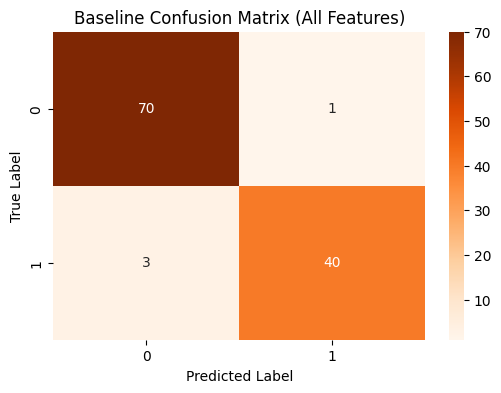


✓ Baseline Results Recorded


In [39]:
# Baseline Model Evaluation
print("=" * 60)
print("EXPERIMENT 0: BASELINE MODEL (ALL FEATURES)")
print("=" * 60)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"\nBaseline Accuracy: {baseline_accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', cbar=True)
plt.title("Baseline Confusion Matrix (All Features)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print("\n✓ Baseline Results Recorded")


# Experiment A: Feature Selection + Gaussian Naive Bayes 🎯
Using SelectKBest with f_classif to select the most relevant features



FEATURE IMPORTANCE ANALYSIS


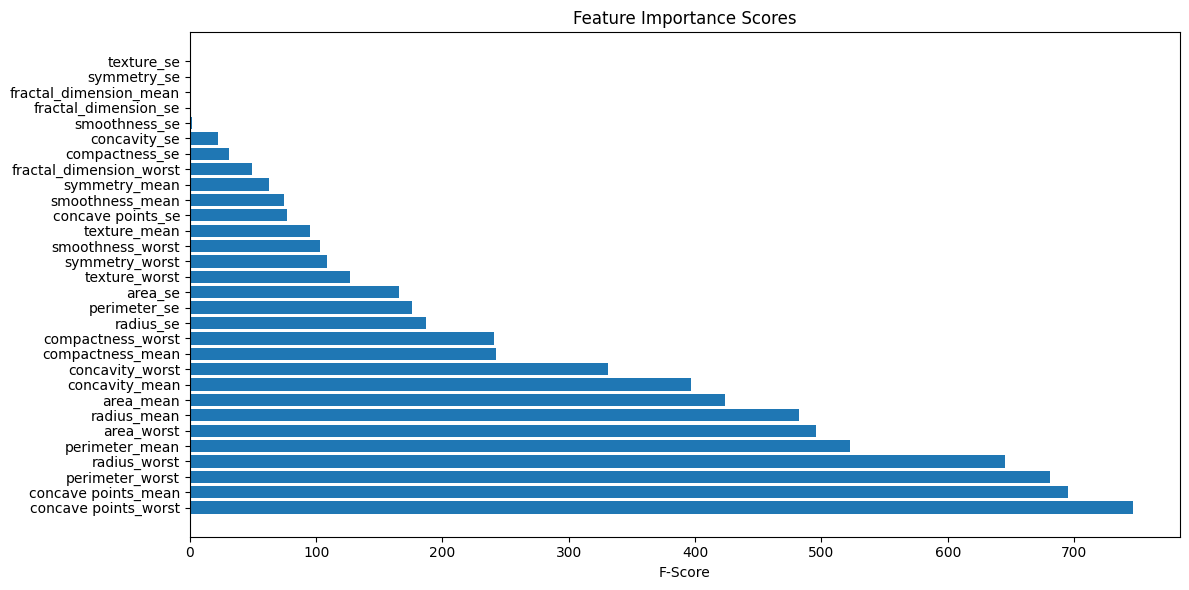


Top 10 Features:
concave points_worst    746.492117
concave points_mean     695.179785
perimeter_worst         681.263759
radius_worst            645.350668
perimeter_mean          522.489267
area_worst              495.787667
radius_mean             482.233945
area_mean               423.654133
concavity_mean          396.662370
concavity_worst         331.330906
dtype: float64


In [40]:
# Visualize Feature Importance
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

sk_all = SelectKBest(score_func=f_classif, k='all')
sk_all.fit(X_train_scaled, y_train)

# Get feature names and scores
feature_names = X.columns.tolist()
feature_scores = pd.Series(sk_all.scores_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(range(len(feature_scores)), feature_scores.values)
plt.yticks(range(len(feature_scores)), feature_scores.index)
plt.xlabel('F-Score')
plt.title('Feature Importance Scores')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feature_scores.head(10))



EXPERIMENT A: FEATURE SELECTION

Testing different k values...
  k=5: Accuracy=94.74%
  k=7: Accuracy=95.61%
  k=9: Accuracy=97.37%
  k=11: Accuracy=96.49%
  k=13: Accuracy=96.49%
  k=15: Accuracy=96.49%
  k=17: Accuracy=96.49%
  k=19: Accuracy=96.49%
  k=21: Accuracy=96.49%
  k=23: Accuracy=96.49%
  k=25: Accuracy=96.49%
  k=27: Accuracy=96.49%
  k=29: Accuracy=96.49%

Best k: 9 with accuracy: 97.37%


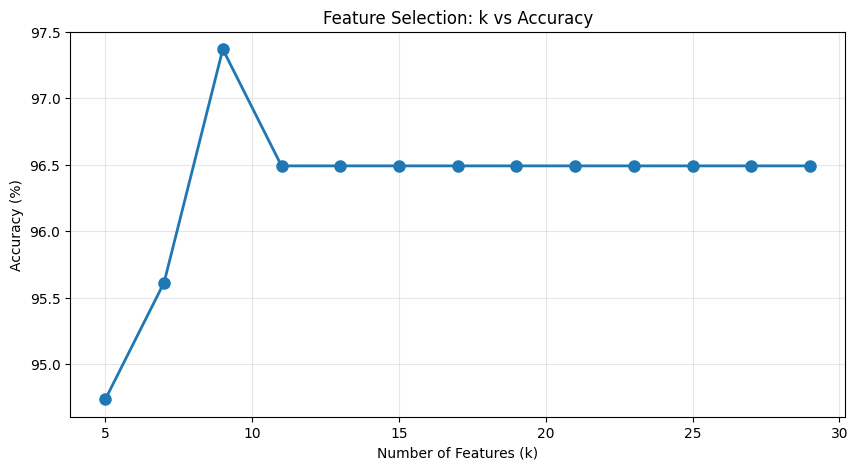

In [41]:
# Feature Selection with different k values
print("\n" + "=" * 60)
print("EXPERIMENT A: FEATURE SELECTION")
print("=" * 60)

n_features = X_train_scaled.shape[1]
k_range = range(5, n_features + 1, 2)
k_scores_fs = {}

print("\nTesting different k values...")
for k in k_range:
    sk = SelectKBest(score_func=f_classif, k=k)
    X_train_fs = sk.fit_transform(X_train_scaled, y_train)
    X_test_fs = sk.transform(X_test_scaled)
    
    gnb_fs = GaussianNB()
    gnb_fs.fit(X_train_fs, y_train)
    y_pred_fs = gnb_fs.predict(X_test_fs)
    
    acc = accuracy_score(y_test, y_pred_fs)
    k_scores_fs[k] = acc
    print(f"  k={k}: Accuracy={acc*100:.2f}%")

# Find best k
best_k = max(k_scores_fs, key=k_scores_fs.get)
print(f"\nBest k: {best_k} with accuracy: {k_scores_fs[best_k]*100:.2f}%")

# Plot k vs accuracy
plt.figure(figsize=(10, 5))
plt.plot(list(k_scores_fs.keys()), [v*100 for v in k_scores_fs.values()], marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Features (k)')
plt.ylabel('Accuracy (%)')
plt.title('Feature Selection: k vs Accuracy')
plt.grid(True, alpha=0.3)
plt.show()



------------------------------------------------------------
FEATURE SELECTION MODEL EVALUATION (k=9)
------------------------------------------------------------

Feature Selection Accuracy: 97.37%
Improvement over Baseline: 0.88%

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        71
   Malignant       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



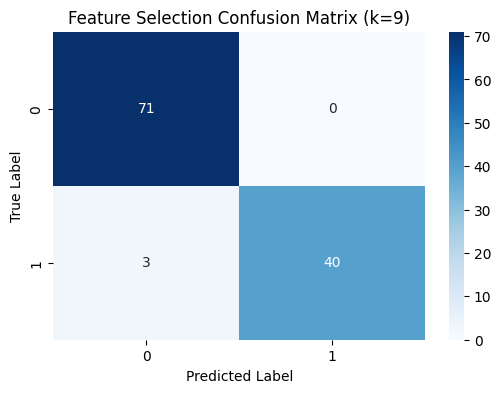


Selected Features (9):
  1. radius_mean
  2. perimeter_mean
  3. area_mean
  4. concavity_mean
  5. concave points_mean
  6. radius_worst
  7. perimeter_worst
  8. area_worst
  9. concave points_worst


In [42]:
# Evaluate Feature Selection Model with Best k
print("\n" + "-" * 60)
print(f"FEATURE SELECTION MODEL EVALUATION (k={best_k})")
print("-" * 60)

sk_best = SelectKBest(score_func=f_classif, k=best_k)
X_train_fs_best = sk_best.fit_transform(X_train_scaled, y_train)
X_test_fs_best = sk_best.transform(X_test_scaled)

gnb_fs_best = GaussianNB()
gnb_fs_best.fit(X_train_fs_best, y_train)
y_pred_fs_best = gnb_fs_best.predict(X_test_fs_best)

fs_accuracy = accuracy_score(y_test, y_pred_fs_best)
print(f"\nFeature Selection Accuracy: {fs_accuracy * 100:.2f}%")
print(f"Improvement over Baseline: {(fs_accuracy - baseline_accuracy) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_fs_best, target_names=['Benign', 'Malignant']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_fs_best), annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f"Feature Selection Confusion Matrix (k={best_k})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Show selected features
selected_features = sk_best.get_support()
selected_feature_names = [feature_names[i] for i in range(len(feature_names)) if selected_features[i]]
print(f"\nSelected Features ({best_k}):")
for i, feat in enumerate(selected_feature_names, 1):
    print(f"  {i}. {feat}")


# Experiment B: PCA (From Scratch) + Gaussian Naive Bayes 📉
Principal Component Analysis for Dimensionality Reduction


In [43]:
def PCA(X, k):
    """
    Principal Component Analysis implementation from scratch.
    
    Steps:
    1. Center the data by subtracting the mean
    2. Calculate the covariance matrix
    3. Compute eigenvalues and eigenvectors
    4. Sort by eigenvalues in descending order
    5. Select top k eigenvectors
    6. Project data onto new axes
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Input data
    k : int
        Number of principal components to keep
    
    Returns:
    --------
    reduced_X : array, shape (n_samples, k)
        Data projected onto principal components
    train_mean : array, shape (n_features,)
        Mean of training data (needed for transforming test data)
    top_k_vectors : array, shape (n_features, k)
        Top k eigenvectors (principal components)
    """
    
    # Center the data
    train_mean = np.mean(X, axis=0)
    centered_X = X - train_mean
    
    # Calculate covariance matrix
    # Covariance = (1/(n-1)) * X^T * X
    n_samples = centered_X.shape[0]
    cov_matrix = (1 / (n_samples - 1)) * (centered_X.T @ centered_X)
    
    # Compute eigenvalues and eigenvectors using numpy.linalg.eigh
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Sort by eigenvalues in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
    cumulative_variance = np.cumsum(variance_ratio)
    
    print(f"\nExplained Variance Ratio (top 10 components):")
    print(cumulative_variance[:10])
    
    # Visualize cumulative variance
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linewidth=2)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.title('PCA: Cumulative Variance Explained')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Select top k eigenvectors
    top_k_vectors = sorted_eigenvectors[:, :k]
    
    # Project data onto new axes
    reduced_X = centered_X @ top_k_vectors
    
    return reduced_X, train_mean, top_k_vectors

def transform_pca(X, train_mean, train_vectors):
    """
    Transform new data using PCA learned from training data.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        New data to transform
    train_mean : array, shape (n_features,)
        Mean from training data
    train_vectors : array, shape (n_features, k)
        Principal components (eigenvectors) from training
    
    Returns:
    --------
    reduced_X : array, shape (n_samples, k)
        Transformed data
    """
    centered_X = X - train_mean
    reduced_X = centered_X @ train_vectors
    return reduced_X

print("\n" + "=" * 60)
print("EXPERIMENT B: PCA (From Scratch)")
print("=" * 60)



EXPERIMENT B: PCA (From Scratch)



Testing different k values for PCA...

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


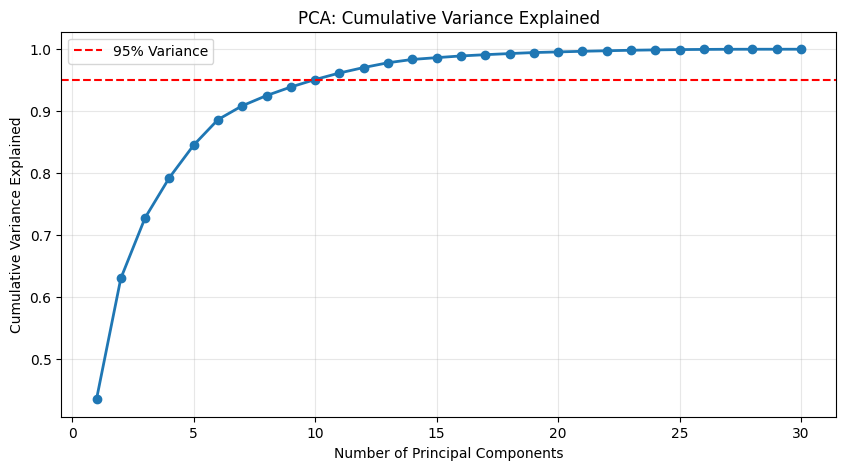

  k=3: Accuracy=94.74%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


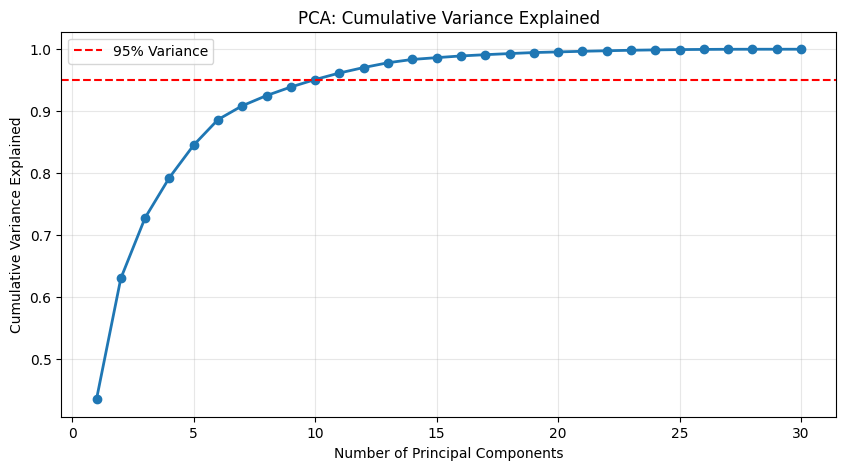

  k=4: Accuracy=93.86%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


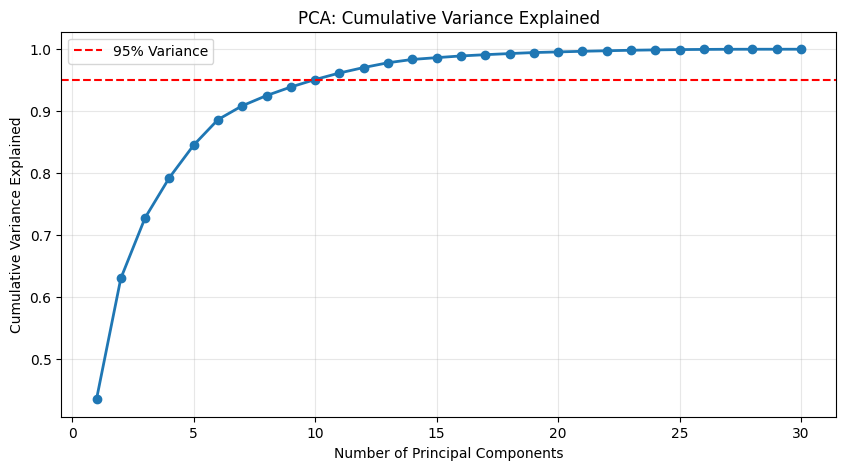

  k=5: Accuracy=94.74%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


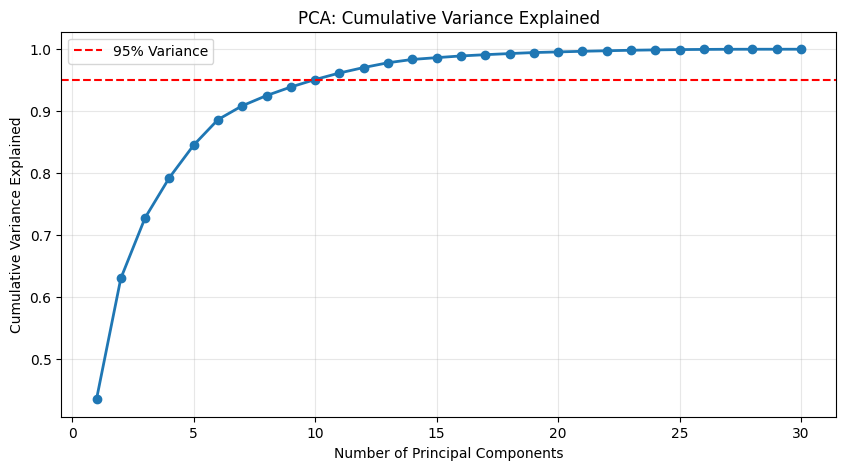

  k=6: Accuracy=94.74%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


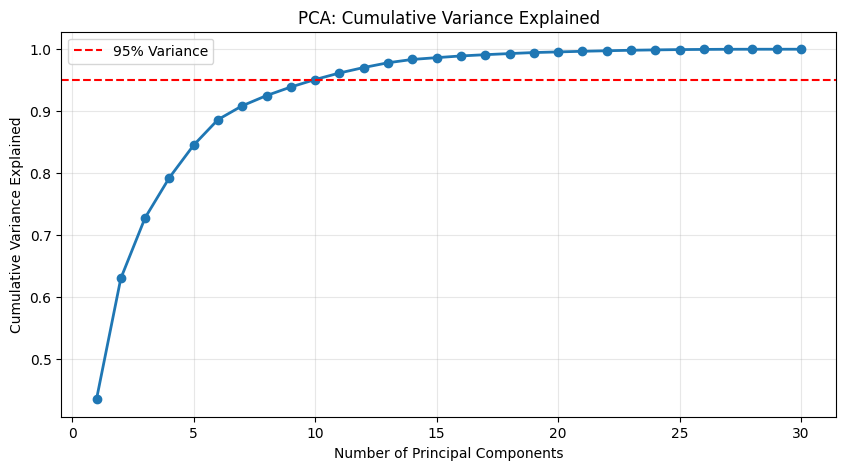

  k=7: Accuracy=91.23%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


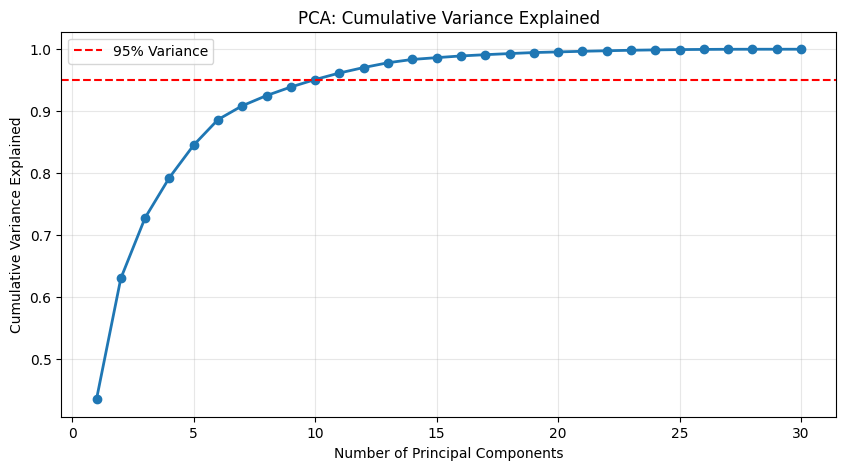

  k=8: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


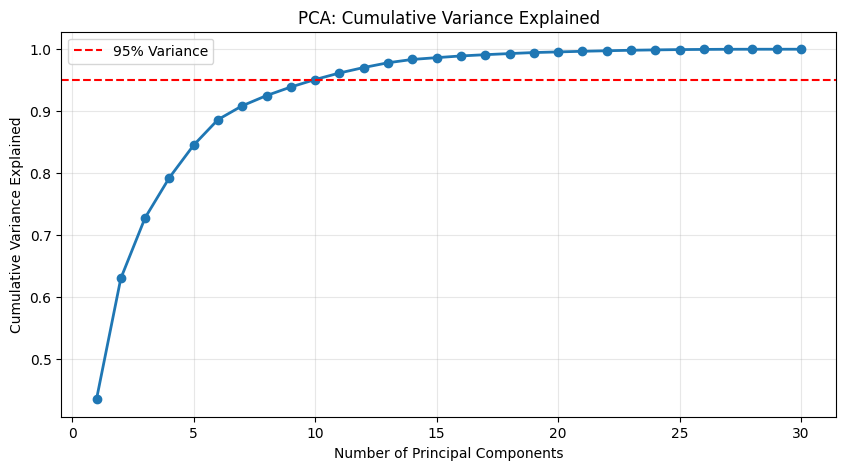

  k=9: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


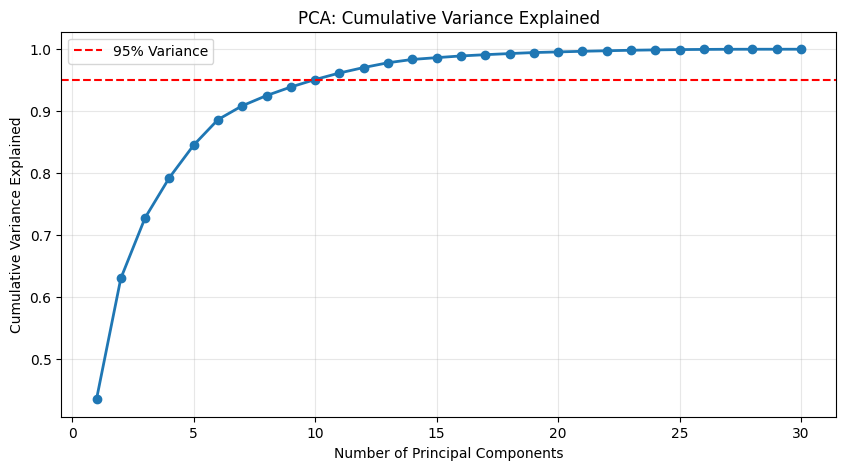

  k=10: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


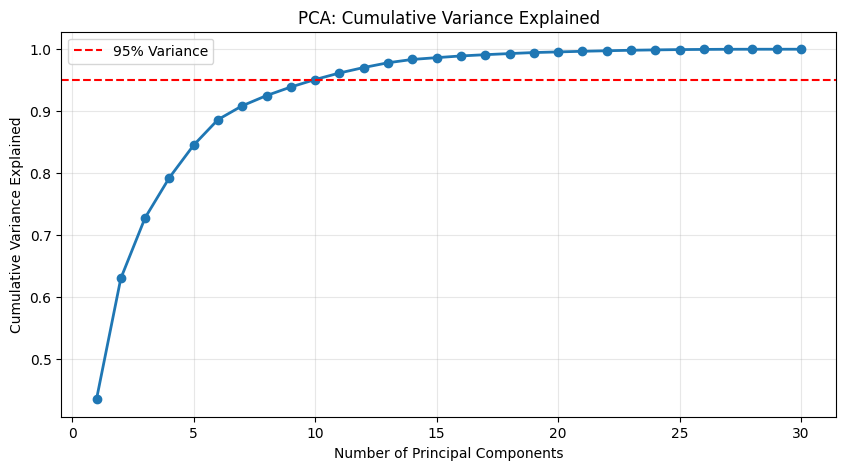

  k=11: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


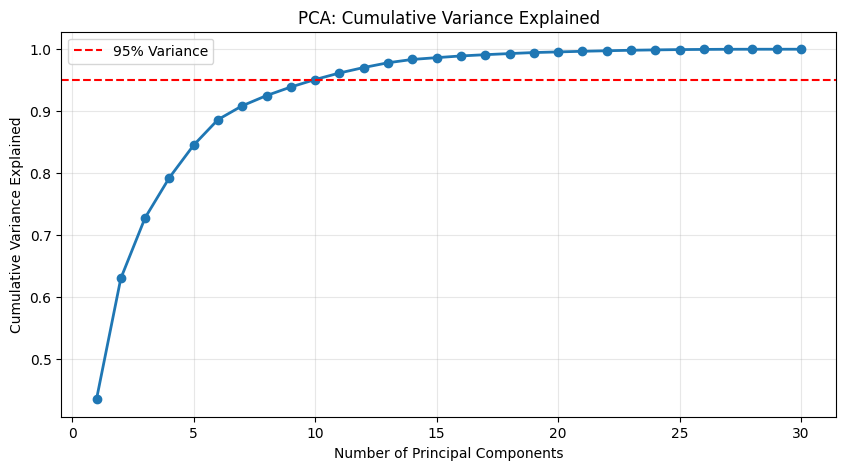

  k=12: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


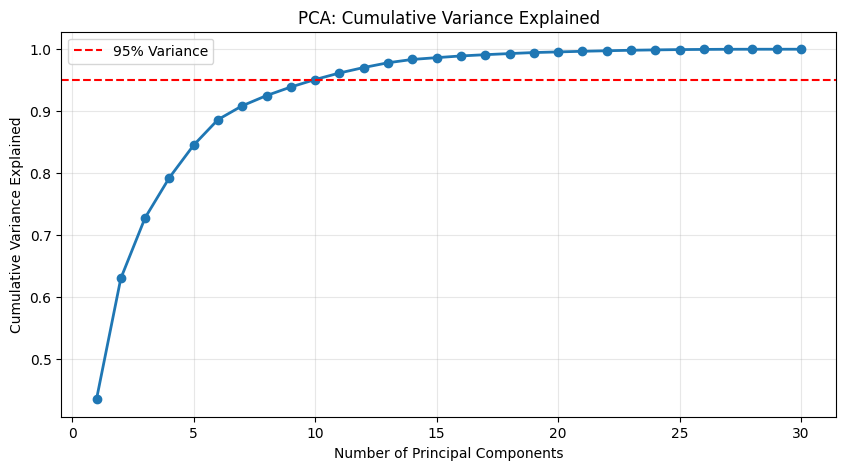

  k=13: Accuracy=93.86%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


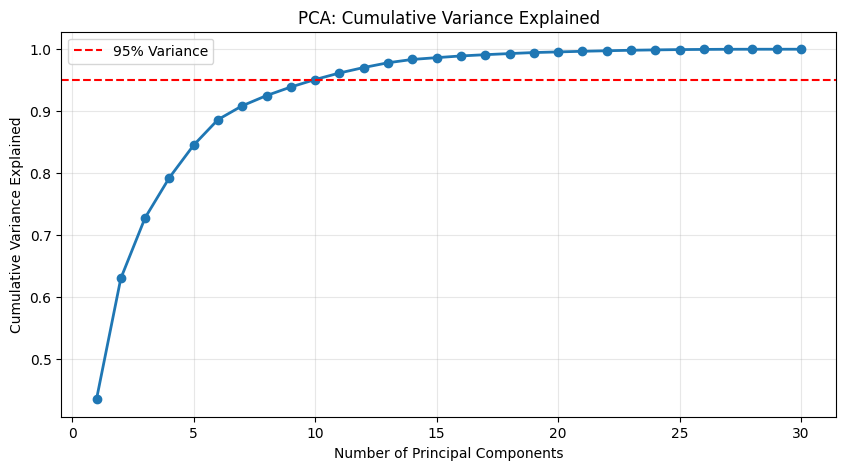

  k=14: Accuracy=93.86%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


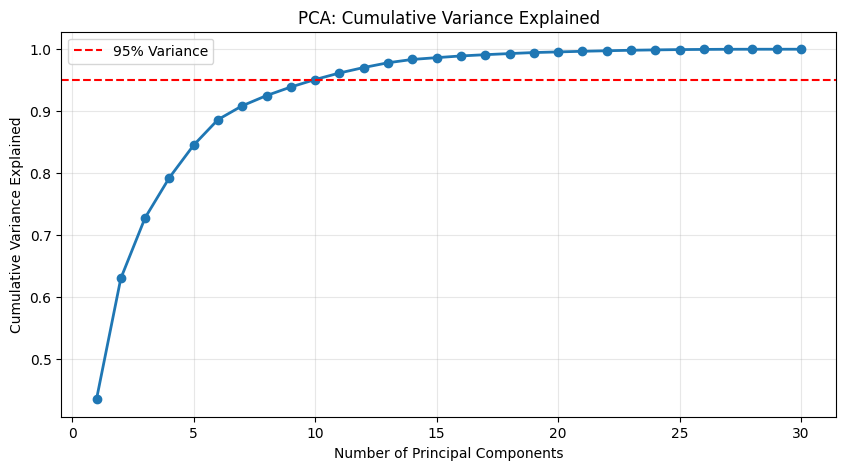

  k=15: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


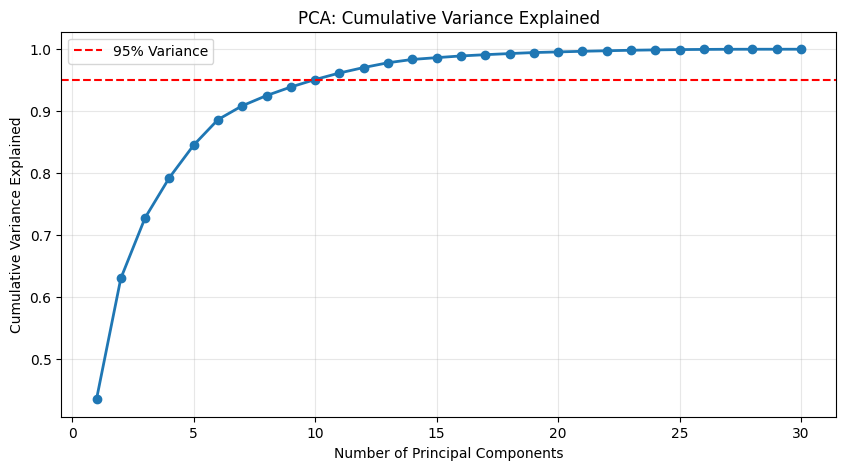

  k=16: Accuracy=92.11%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


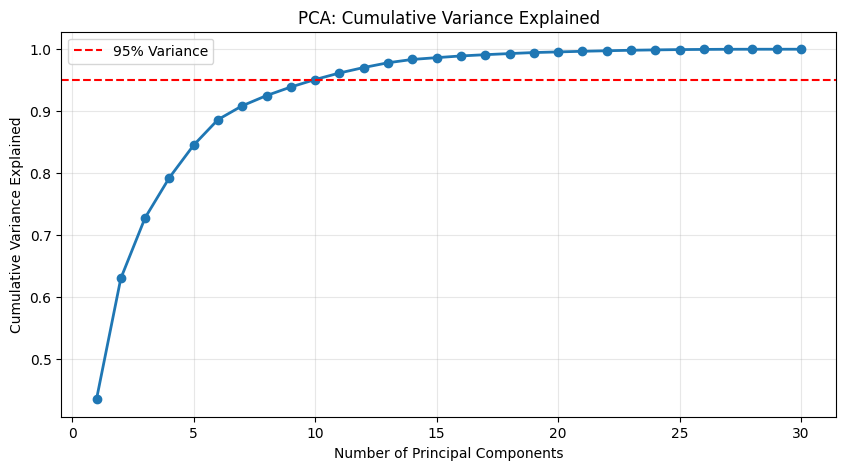

  k=17: Accuracy=90.35%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


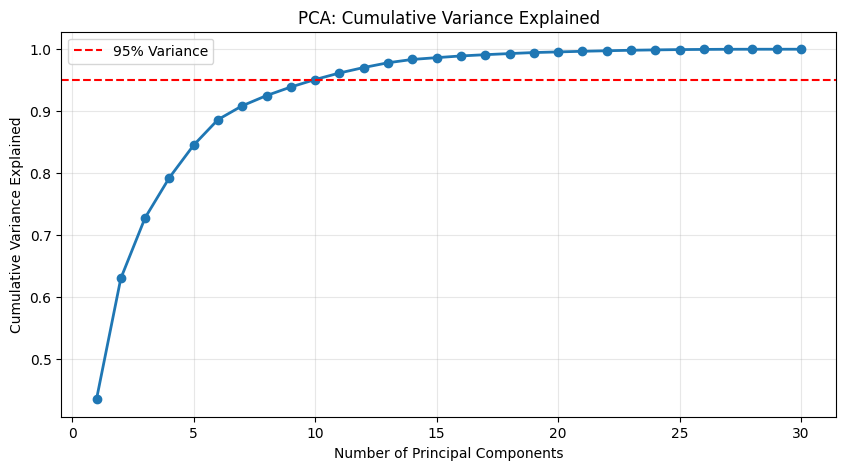

  k=18: Accuracy=89.47%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


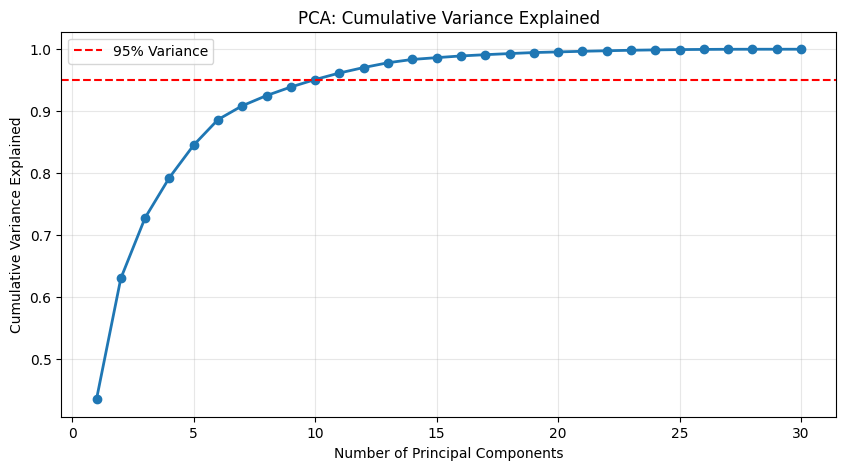

  k=19: Accuracy=87.72%

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


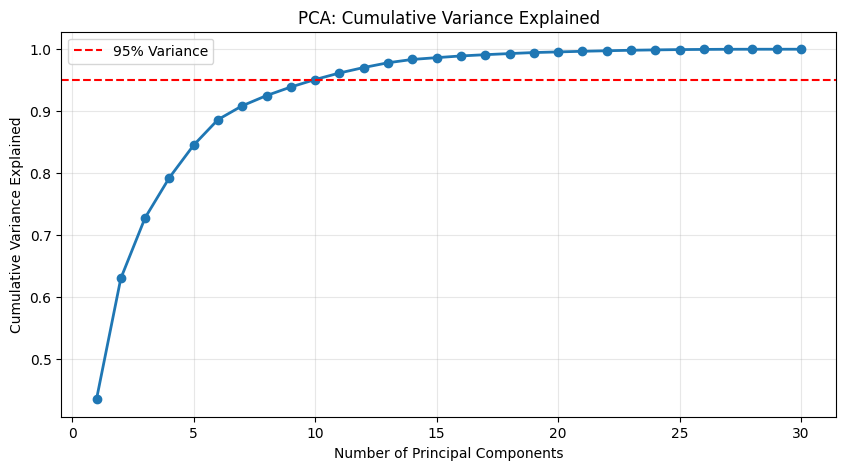

  k=20: Accuracy=89.47%

Best k for PCA: 3 with accuracy: 94.74%


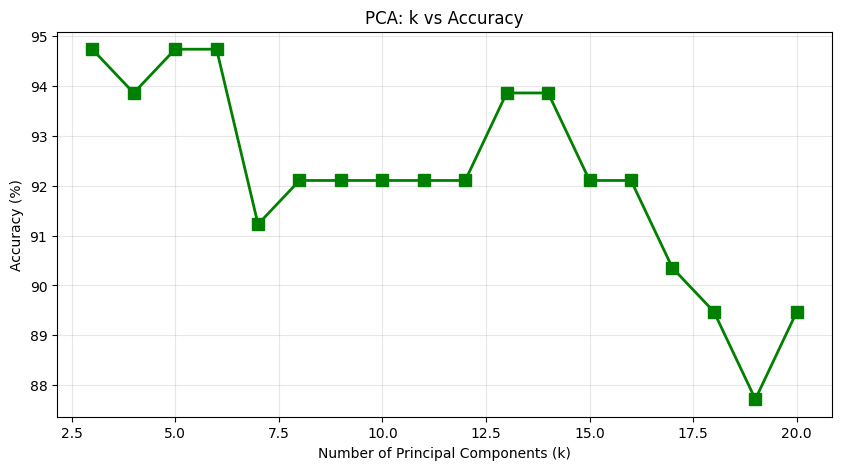

In [44]:
# Test PCA with different k values
k_range_pca = range(3, 21)
k_scores_pca = {}

print("\nTesting different k values for PCA...")
for k in k_range_pca:
    X_train_pca, train_mean, train_vectors = PCA(X_train_scaled, k)
    X_test_pca = transform_pca(X_test_scaled, train_mean, train_vectors)
    
    gnb_pca = GaussianNB()
    gnb_pca.fit(X_train_pca, y_train)
    y_pred_pca = gnb_pca.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred_pca)
    k_scores_pca[k] = acc
    print(f"  k={k}: Accuracy={acc*100:.2f}%")

# Find best k for PCA
best_k_pca = max(k_scores_pca, key=k_scores_pca.get)
print(f"\nBest k for PCA: {best_k_pca} with accuracy: {k_scores_pca[best_k_pca]*100:.2f}%")

# Plot k vs accuracy for PCA
plt.figure(figsize=(10, 5))
plt.plot(list(k_scores_pca.keys()), [v*100 for v in k_scores_pca.values()], marker='s', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Accuracy (%)')
plt.title('PCA: k vs Accuracy')
plt.grid(True, alpha=0.3)
plt.show()



------------------------------------------------------------
PCA MODEL EVALUATION (k=3)
------------------------------------------------------------

Explained Variance Ratio (top 10 components):
[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751]


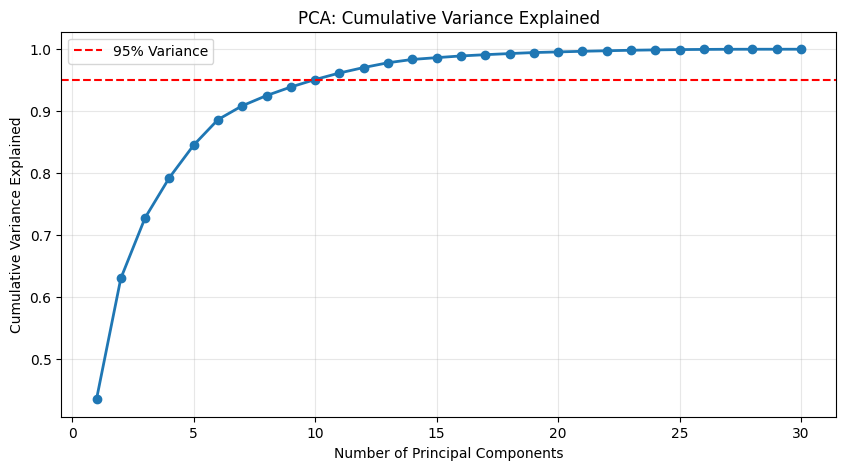


PCA Accuracy: 94.74%
Improvement over Baseline: -1.75%
Dimensionality Reduction: 30 → 3 features

Classification Report:
               precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        71
   Malignant       0.97      0.88      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



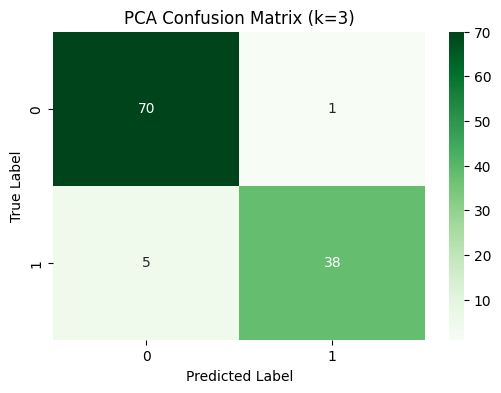

In [45]:
# Evaluate PCA Model with Best k
print("\n" + "-" * 60)
print(f"PCA MODEL EVALUATION (k={best_k_pca})")
print("-" * 60)

X_train_pca_best, train_mean_best, train_vectors_best = PCA(X_train_scaled, best_k_pca)
X_test_pca_best = transform_pca(X_test_scaled, train_mean_best, train_vectors_best)

gnb_pca_best = GaussianNB()
gnb_pca_best.fit(X_train_pca_best, y_train)
y_pred_pca_best = gnb_pca_best.predict(X_test_pca_best)

pca_accuracy = accuracy_score(y_test, y_pred_pca_best)
print(f"\nPCA Accuracy: {pca_accuracy * 100:.2f}%")
print(f"Improvement over Baseline: {(pca_accuracy - baseline_accuracy) * 100:.2f}%")
print(f"Dimensionality Reduction: {X_train_scaled.shape[1]} → {best_k_pca} features")
print("\nClassification Report:\n", classification_report(y_test, y_pred_pca_best, target_names=['Benign', 'Malignant']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_pca_best), annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title(f"PCA Confusion Matrix (k={best_k_pca})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


# Comparative Analysis 🏆
Comparison of All Three Approaches



COMPARATIVE ANALYSIS SUMMARY

                  Model  Accuracy  Improvement  Features/Components
Baseline (All Features) 96.491228     0.000000                   30
Feature Selection (k=9) 97.368421     0.877193                    9
              PCA (k=3) 94.736842    -1.754386                    3

✓ Best Model: Feature Selection (k=9) (Accuracy: 97.37%)


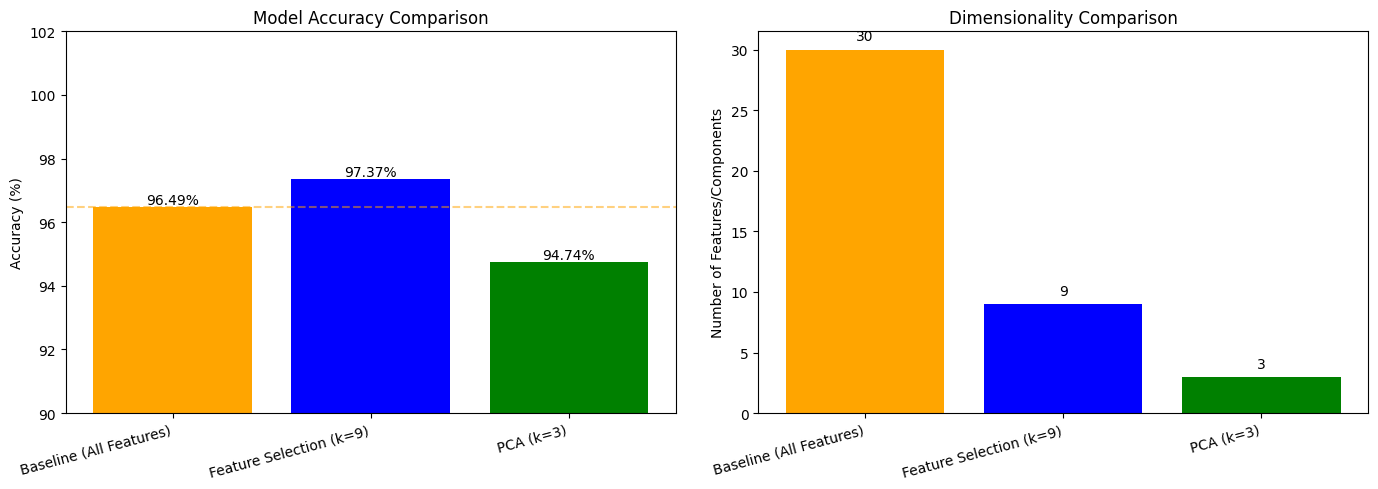


KEY INSIGHTS
• Baseline uses all 30 features
• Feature Selection selected 9 most important features
  - Reduction: 70.0%
• PCA reduced to 3 principal components
  - Reduction: 90.0%

• Best Accuracy: 97.37% (Feature Selection (k=9))
• Best Accuracy Improvement: 0.88% over baseline


In [46]:
print("\n" + "=" * 60)
print("COMPARATIVE ANALYSIS SUMMARY")
print("=" * 60)

# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': [
        'Baseline (All Features)',
        f'Feature Selection (k={best_k})',
        f'PCA (k={best_k_pca})'
    ],
    'Accuracy': [baseline_accuracy * 100, fs_accuracy * 100, pca_accuracy * 100],
    'Improvement': [
        0,
        (fs_accuracy - baseline_accuracy) * 100,
        (pca_accuracy - baseline_accuracy) * 100
    ],
    'Features/Components': [
        X_train_scaled.shape[1],
        best_k,
        best_k_pca
    ]
})

print("\n" + results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print(f"\n✓ Best Model: {best_model_name} (Accuracy: {best_accuracy:.2f}%)")

# Visualization 1: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(range(len(results_df)), results_df['Accuracy'], color=['orange', 'blue', 'green'])
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([90, 102])
axes[0].axhline(y=baseline_accuracy * 100, color='orange', linestyle='--', alpha=0.5, label='Baseline')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom')

# Feature Reduction Comparison
axes[1].bar(range(len(results_df)), results_df['Features/Components'], color=['orange', 'blue', 'green'])
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].set_ylabel('Number of Features/Components')
axes[1].set_title('Dimensionality Comparison')

# Add values on bars
for i, v in enumerate(results_df['Features/Components']):
    axes[1].text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print(f"• Baseline uses all {X_train_scaled.shape[1]} features")
print(f"• Feature Selection selected {best_k} most important features")
print(f"  - Reduction: {(1 - best_k/X_train_scaled.shape[1])*100:.1f}%")
print(f"• PCA reduced to {best_k_pca} principal components")
print(f"  - Reduction: {(1 - best_k_pca/X_train_scaled.shape[1])*100:.1f}%")
print(f"\n• Best Accuracy: {best_accuracy:.2f}% ({best_model_name})")
print(f"• Best Accuracy Improvement: {results_df['Improvement'].max():.2f}% over baseline")
print("=" * 60)
